# Metrics

In [1]:
import os, json
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score
from utils import getCausalMatrix

def shd_score(a_true, a_pred):
    diff = np.abs(a_true - a_pred)
    return int(diff.sum())

GC = getCausalMatrix(n_dim=10, data='henon')

parent = os.path.join(os.path.abspath(''), 'artifacts_henon')
artifact_name = "trf___adaptive_global___henon___30-01-2026_12-05-24"

with open(os.path.join(parent, artifact_name, 'metadata_comb1.json'), 'r') as f:
    metadata = json.load(f)

print(f"\n{artifact_name}:\t{metadata['dataset']}\t{metadata['combination']}")
print(f"Best Val loss: {metadata['best_val_loss']}")
gc_raw = metadata['GC_raw']
gc_est = metadata['GC_est']
print(f"AUROC: {roc_auc_score(GC, gc_raw)}") # Raw GC matrix
print(f"F1-Score: {f1_score(GC, gc_est, average='macro')}") # Binarized GC matrix
print(f"SHD Score: {shd_score(GC, gc_est)}") # Binarized GC matrix


trf___adaptive_global___henon___30-01-2026_12-05-24:	henon_5000_10	1
Best Val loss: 1.5803729392126242
AUROC: 1.0
F1-Score: 1.0
SHD Score: 0


# Convergence Plots

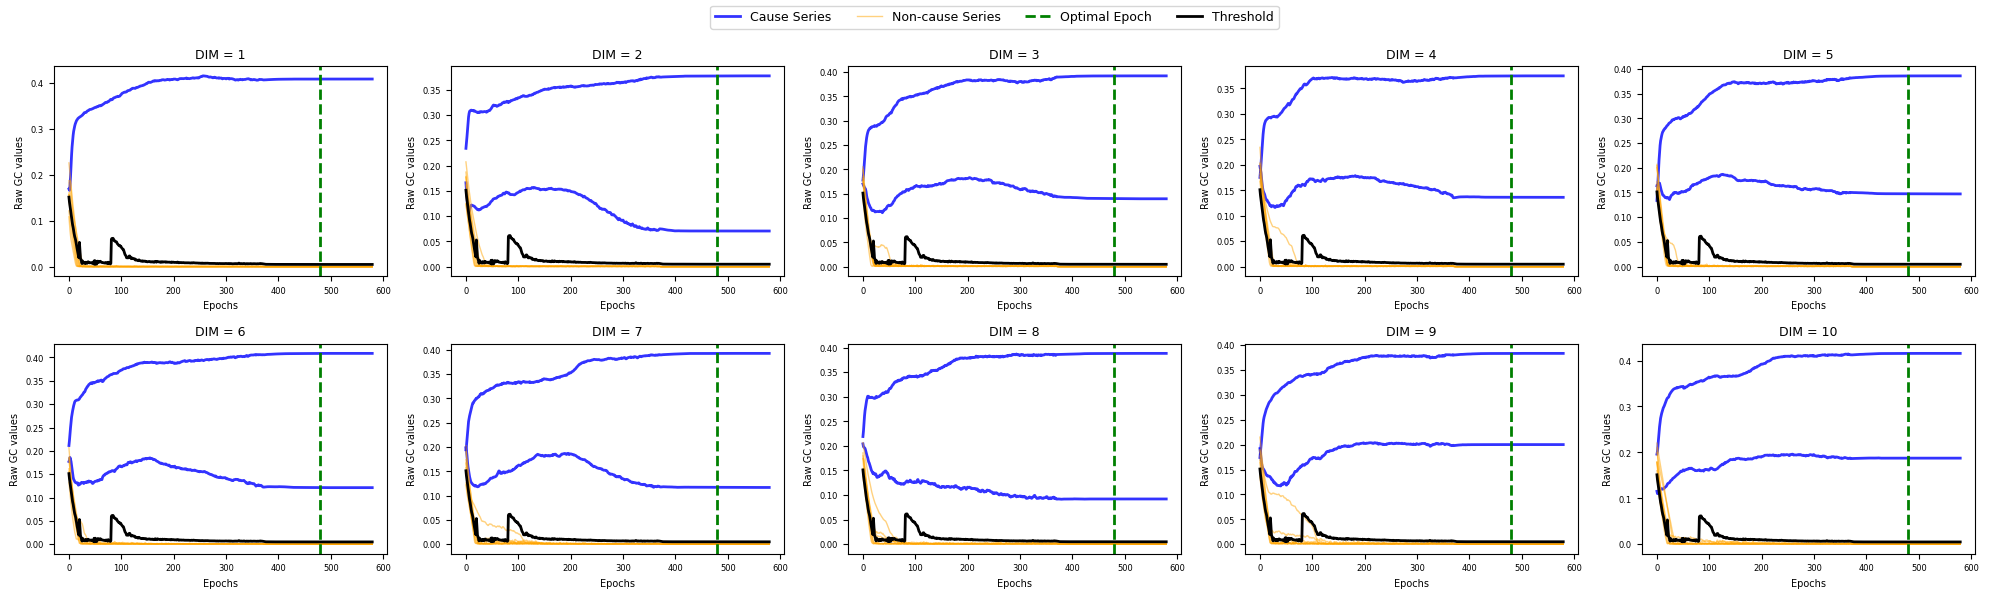

In [2]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from utils import getCausalMatrix
import math

GC = getCausalMatrix(n_dim=10, data='henon')

parent = os.path.join(os.path.abspath(''), 'artifacts_henon')
artifact_name = "trf___adaptive_global___henon___30-01-2026_12-05-24"

with open(os.path.join(parent, artifact_name, 'metadata_comb1.json'), 'r') as f:
    metadata = json.load(f)

n_dim = metadata['n_dim']
gc_raw = metadata['GC_raw']
gc_est = metadata['GC_est']
optimal_epoch = metadata['optimal_epoch']
gc_raw_list = metadata['gc_raw_list']
gc_est_list = metadata['gc_est_list']
threshold_list = metadata['threshold_list']

data = np.array(gc_raw_list)
start = 0 # For fine-grained visualization towards end
n_rows = 2  # user-defined number of rows
n_cols = math.ceil(n_dim / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)
axes = axes.flatten()
for dim in range(n_dim):
    ax = axes[dim]

    group_1 = np.where(GC[dim] == 1)[0].tolist()
    group_2 = np.where(GC[dim] == 0)[0].tolist()

    for i, col in enumerate(group_1):
        ax.plot(data[start:, dim, col], color="blue", alpha=0.8, linewidth=2, label="Cause Series" if i == 0 else None)
    
    for i, col in enumerate(group_2):
        ax.plot(data[start:, dim, col], color="orange", alpha=0.5, linewidth=1, label="Non-cause Series" if i == 0 else None)

    ax.axvline(x=optimal_epoch - start, color="green", linestyle="--", linewidth=2, label="Optimal Epoch")
    ax.plot(threshold_list[start:], color="black", linewidth=2, label="Threshold")

    ax.set_title(f"DIM = {dim + 1}", fontsize=9)
    ax.set_xlabel("Epochs", fontsize=7)
    ax.set_ylabel("Raw GC values", fontsize=7)
    ax.tick_params(axis="both", labelsize=6)

for k in range(n_dim, n_rows * n_cols):
    axes[k].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Causal Matrix Plots

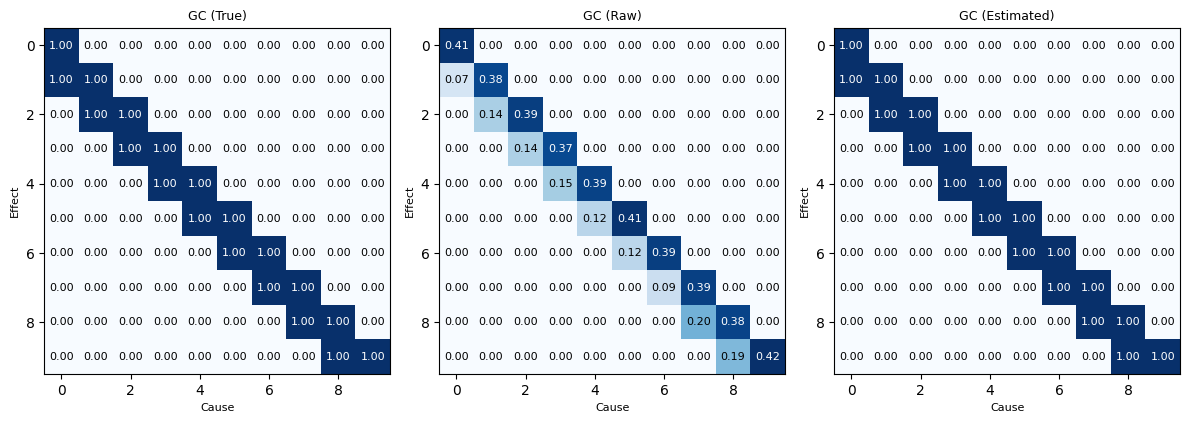

In [3]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from utils import getCausalMatrix

gc_true = getCausalMatrix(n_dim=10, data='henon')

parent = os.path.join(os.path.abspath(''), 'artifacts_henon')
artifact_name = "trf___adaptive_global___henon___30-01-2026_12-05-24"

with open(os.path.join(parent, artifact_name, 'metadata_comb1.json'), 'r') as f:
    metadata = json.load(f)

n_dim = metadata['n_dim']
gc_raw = np.array(metadata['GC_raw'])
gc_est = np.array(metadata['GC_est'])
optimal_epoch = metadata['optimal_epoch']
threshold_list = metadata['threshold_list']

def plot_gc(ax, gc, title, *, use_epoch_threshold=False, diagonal_white_only=False):
    im = ax.imshow(gc, cmap="Blues", interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Cause", fontsize=8)
    ax.set_ylabel("Effect", fontsize=8)

    if use_epoch_threshold:
        threshold = threshold_list[optimal_epoch]
    else:
        threshold = 0.5 * (gc.max() + gc.min())

    for i in range(gc.shape[0]):
        for j in range(gc.shape[1]):
            if diagonal_white_only:
                color = "white" if i == j else "black"
            else:
                color = "white" if gc[i, j] > threshold else "black"
            ax.text(j, i, f"{gc[i, j]:.2f}", ha="center", va="center", color=color, fontsize=8)
    return im

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
plot_gc(axes[0], gc_true, title="GC (True)", use_epoch_threshold=False, diagonal_white_only=False)
plot_gc(axes[1], gc_raw, title="GC (Raw)", use_epoch_threshold=True, diagonal_white_only=True)
plot_gc(axes[2], gc_est, title="GC (Estimated)", use_epoch_threshold=False, diagonal_white_only=False)

plt.tight_layout()
plt.show()